## MARBL diagnostics, compare timeseries of global metrics between multiple cases (only 2-d variables)


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import pandas as pd
import matplotlib.gridspec as gridspec
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Come up with short names for each case

In [2]:
short_names = ['005','006','007'
              ]

### Define number of years and number of cases

In [3]:
num_cases = len(short_names)
num_years = 50 #max years in any of the runs

### Define cases

In [4]:
sandbox = 'g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37'

case_nums = ['005','006','007']

user = 'klindsay'

### Define the year range

In [5]:
start_yr = 37
endyr = start_yr + num_years 

### 2-D variable list

In [6]:
variables2d = ['calcToSed','pocToSed','DIC_RIV_FLUX','DOC_RIV_FLUX','DOCR_RIV_FLUX','pocToFloor'] 

coords = {'x':'yh','y':'xh'}


keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables2d + list(coords.values())

### Get dask going

In [7]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='25 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=25GB',
        project='NCGD0011',
        walltime='03:00:00',
        interface='ext',
        log_directory='./dask-logs')

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [8]:
cluster, client = get_ClusterClient()
cluster.scale(12) 
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/40851/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/40851/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.195:36849,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/40851/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Read in all the data

In [9]:
cases_dict = {}

for case_num in case_nums:
    case = sandbox + '.' + case_num
    print(case)
    files = []
    for year in range(start_yr,endyr):
        yr4="{:04d}".format(year)
        #print('doing simulation year', year, '!')
        
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.native_annual.{yr4}.nc')))
    ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested' )
    ### drop unnecessary variables
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
    ### resample to annual means
    cases_dict[case_num] = ds_tmp #.resample({'time':'A'}).mean(dim='time', keep_attrs=True).compute()

g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.005
g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.006
g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.007


In [10]:
cases_dict.keys()

dict_keys(['005', '006', '007'])

## Get the grid data for MOM6

In [11]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')

In [12]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

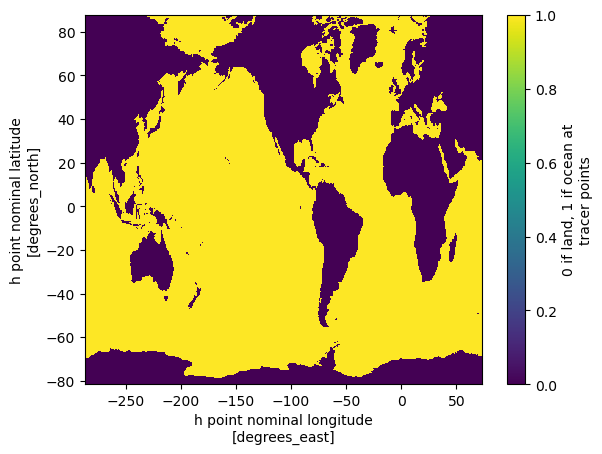

In [13]:
ds_grid.wet.plot()

### Global totals

In [14]:
mmols_to_PgCyr = 1e-3 * 12. * 1e-15 * 365. * 86400.

variables = variables2d

glb_ds_dict = {}

for case_num in case_nums:
    
    case = sandbox + '.' + case_num

    ds_glb = xr.Dataset()

    ds = cases_dict[case_num]
    
    for v in variables:
        ds_glb[v] = ((ds[v] * area).sum(dim=('xh', 'yh'))).compute() #mmol/m
        ds_glb[v].attrs = ds[v].attrs
    
        ds_glb[v] = ds_glb[v] * mmols_to_PgCyr        
        ds_glb[v].attrs['units'] = 'Pg C yr$^{-1}$'

    
    ds_glb = ds_glb.compute()

    glb_ds_dict[case_num] = ds_glb

In [15]:
glb_ds_dict['005']

<xarray.Dataset> Size: 2kB
Dimensions:        (time: 50)
Coordinates:
  * time           (time) object 400B 0037-07-02 12:00:00 ... 0086-07-02 12:0...
Data variables:
    calcToSed      (time) float32 200B 0.1234 0.132 0.1298 ... 0.1328 0.1327
    pocToSed       (time) float32 200B 0.135 0.1422 0.1469 ... 0.147 0.1475
    DIC_RIV_FLUX   (time) float32 200B 0.0 0.0 0.0 0.0 ... 0.2646 0.2646 0.2646
    DOC_RIV_FLUX   (time) float32 200B 0.0 0.0 0.0 0.0 ... 0.1388 0.1388 0.1388
    DOCR_RIV_FLUX  (time) float32 200B 0.0 0.0 0.0 ... 0.03471 0.03471 0.03471
    pocToFloor     (time) float32 200B 0.0 0.0 0.0 0.0 ... 0.9028 0.9067 0.9014

### Make a mean over the last 25 years of run or however many years we have of necessary output

In [16]:
mean_glb_dict = {}

for case in cases_dict.keys():
    print(case)

    mean_glb_dict[case] = glb_ds_dict[case].isel(time=slice(-20, None)).mean(dim="time")

005
006
007


### Compute Carbon balance

In [17]:
for case in case_nums:

    print(case, ' CARBON BALANCE')
    print('--------------')
    print('calcToSed = ', np.round(mean_glb_dict[case].calcToSed.values,3), ' Pg C/yr')
    print('pocToSed = ', np.round(mean_glb_dict[case].pocToSed.values,3), ' Pg C/yr')
    print('DIC_RIV_FLUX = ',np.round(mean_glb_dict[case].DIC_RIV_FLUX.values,3), ' Pg C/yr')
    print('DOC_RIV_FLUX = ',np.round(mean_glb_dict[case].DOC_RIV_FLUX.values,3), ' Pg C/yr')
    print('DOCR_RIV_FLUX = ',np.round(mean_glb_dict[case].DOCR_RIV_FLUX.values,3), ' Pg C/yr')
    print()
    print('TOTAL OUT = ', np.round(mean_glb_dict[case].calcToSed.values+mean_glb_dict[case].pocToSed.values,3),' Pg C/yr')
    print('TOTAL IN = ', np.round(mean_glb_dict[case].DIC_RIV_FLUX.values+mean_glb_dict[case].DOC_RIV_FLUX.values+mean_glb_dict[case].DOCR_RIV_FLUX.values,3),' Pg C/yr')
    print()
    print('BALANCE = ', np.round((mean_glb_dict[case].DIC_RIV_FLUX.values+mean_glb_dict[case].DOC_RIV_FLUX.values+mean_glb_dict[case].DOCR_RIV_FLUX.values)-(mean_glb_dict[case].calcToSed.values+mean_glb_dict[case].pocToSed.values),3))
    print()


005  CARBON BALANCE
--------------
calcToSed =  0.131  Pg C/yr
pocToSed =  0.147  Pg C/yr
DIC_RIV_FLUX =  0.265  Pg C/yr
DOC_RIV_FLUX =  0.139  Pg C/yr
DOCR_RIV_FLUX =  0.035  Pg C/yr

TOTAL OUT =  0.278  Pg C/yr
TOTAL IN =  0.438  Pg C/yr

BALANCE =  0.16

006  CARBON BALANCE
--------------
calcToSed =  0.13  Pg C/yr
pocToSed =  0.26  Pg C/yr
DIC_RIV_FLUX =  0.265  Pg C/yr
DOC_RIV_FLUX =  0.139  Pg C/yr
DOCR_RIV_FLUX =  0.035  Pg C/yr

TOTAL OUT =  0.391  Pg C/yr
TOTAL IN =  0.438  Pg C/yr

BALANCE =  0.048

007  CARBON BALANCE
--------------
calcToSed =  0.13  Pg C/yr
pocToSed =  0.268  Pg C/yr
DIC_RIV_FLUX =  0.265  Pg C/yr
DOC_RIV_FLUX =  0.139  Pg C/yr
DOCR_RIV_FLUX =  0.035  Pg C/yr

TOTAL OUT =  0.398  Pg C/yr
TOTAL IN =  0.438  Pg C/yr

BALANCE =  0.04



### Compute Alkalinity balance

In [20]:
for case in case_nums:

    print(case, ' ALKALINITY BALANCE')
    print('--------------')
    print('calcToSed = ', np.round(mean_glb_dict[case].calcToSed.values,3), ' Pg C/yr')
    print('DIC_RIV_FLUX = ',np.round(mean_glb_dict[case].DIC_RIV_FLUX.values,3), ' Pg C/yr')
    print()
    print('TOTAL OUT = ', np.round(2 * mean_glb_dict[case].calcToSed.values,3),' Pg C/yr')
    print('TOTAL IN = ', np.round(mean_glb_dict[case].DIC_RIV_FLUX.values,3),' Pg C/yr')
    print()
    print('BALANCE = ', np.round((mean_glb_dict[case].DIC_RIV_FLUX.values) - (2 * mean_glb_dict[case].calcToSed.values),3))

005  ALKALINITY BALANCE
--------------
calcToSed =  0.131  Pg C/yr
DIC_RIV_FLUX =  0.265  Pg C/yr

TOTAL OUT =  0.262  Pg C/yr
TOTAL IN =  0.265  Pg C/yr

BALANCE =  0.002
006  ALKALINITY BALANCE
--------------
calcToSed =  0.13  Pg C/yr
DIC_RIV_FLUX =  0.265  Pg C/yr

TOTAL OUT =  0.261  Pg C/yr
TOTAL IN =  0.265  Pg C/yr

BALANCE =  0.004
007  ALKALINITY BALANCE
--------------
calcToSed =  0.13  Pg C/yr
DIC_RIV_FLUX =  0.265  Pg C/yr

TOTAL OUT =  0.26  Pg C/yr
TOTAL IN =  0.265  Pg C/yr

BALANCE =  0.005
